# Phase 2: Statistical analysis:

First, we set up the environment with the necessary libraries:

In [14]:
# Libraries for data processing:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # To be able to see all columns from the data frames

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
from scipy.stats import shapiro, kstest

# Gestión de los warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load the clean csv files as dataframes:

df_flights = pd.read_csv("clean-data/customer-flight-activity-clean.csv")
df_customers = pd.read_csv("clean-data/customer-loyal-history-clean.csv")
df_master = pd.read_csv("clean-data/merged-master-data.csv")
df_merged_customers_who_fly = pd.read_csv("clean-data/merged-customers-who-fly.csv")


In [6]:
display(df_flights.head(3))
print("="*150)
display(df_customers.head(3))
print("="*150)
display(df_master.head(3))
print("="*150)
display(df_merged_customers_who_fly.head(3))

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
1,100102,2017,January,10,4,14,2030,203.0,0,0
2,100140,2017,January,6,0,6,1200,120.0,0,0


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,July


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2017,January,3,0,3,1521,152.0,0,0
1,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2017,February,2,2,4,1320,132.0,0,0
2,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2018,October,6,4,10,3110,311.0,385,31


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2017,January,3,0,3,1521,152.0,0,0
1,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2017,February,2,2,4,1320,132.0,0,0
2,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,2018,October,6,4,10,3110,311.0,385,31


### Identification of all numerical and categorical columns

In [7]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               403760 non-null  int64  
 1   year                         403760 non-null  int64  
 2   month                        403760 non-null  str    
 3   flights_booked               403760 non-null  int64  
 4   flights_with_companions      403760 non-null  int64  
 5   total_flights                403760 non-null  int64  
 6   distance                     403760 non-null  int64  
 7   points_accumulated           403760 non-null  float64
 8   points_redeemed              403760 non-null  int64  
 9   dollar_cost_points_redeemed  403760 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 30.8 MB


In [11]:
col_numerical_flights = df_flights.select_dtypes(include = "number").columns
col_numerical_flights

Index(['loyalty_number', 'year', 'flights_booked', 'flights_with_companions',
       'total_flights', 'distance', 'points_accumulated', 'points_redeemed',
       'dollar_cost_points_redeemed'],
      dtype='str')

In [10]:
col_categorical_flights = df_flights.select_dtypes(include = "str").columns
col_categorical_flights


Index(['month'], dtype='str')

In [12]:
col_numerical_customers = df_customers.select_dtypes(include = "number").columns
col_numerical_customers


Index(['loyalty_number', 'salary', 'clv', 'enrollment_year'], dtype='str')

In [13]:
col_categorical_customers = df_customers.select_dtypes(include = "str").columns
col_categorical_customers

Index(['country', 'province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type',
       'enrollment_month'],
      dtype='str')

## 1. Numerical variables analysis

### 1. Descriptive statistics (mean, median, mode, standard deviation etc)

In [16]:
print(col_numerical_customers)
print(col_numerical_flights)

Index(['loyalty_number', 'salary', 'clv', 'enrollment_year'], dtype='str')
Index(['loyalty_number', 'year', 'flights_booked', 'flights_with_companions',
       'total_flights', 'distance', 'points_accumulated', 'points_redeemed',
       'dollar_cost_points_redeemed'],
      dtype='str')


Let's start with the customers dataframe:

In [17]:
relevant_numerical_customers = ["salary", "clv", "enrollment_year"]
relevant_numerical_customers

['salary', 'clv', 'enrollment_year']

In [ ]:
df_customers[relevant_numerical_customers].describe().T
# Salary:
    # As previously seen during phase 1. The count of salaries is less since some of the values are null. 
    # The mean and median (50% in the table) differ a bit. It seems the extreme high salary values are bring the mean to the right. 
# clv: 
    # The mean and median differ. Same as with the salary, the high extreme values are bringing the mean to the right. 
# enrollment_year:
    # For this variable, the only "relevant" information is to know that the earliest enrolllment year was in 2012 and the latest in 2018.


,count,mean,std,min,25%,50%,75%,max
salary,11027.0,79451.765213,35004.191059,15609.00,59221.500,73398.00,88595.0000,407228.00
clv,14778.0,8003.704467,6900.522938,1898.01,3964.245,5780.18,8995.7725,83325.38
enrollment_year,14778.0,2015.250711,1.983899,2012.00,2014.000,2015.00,2017.0000,2018.00


In [23]:
mean_salary = round(df_customers["salary"].mean(),2)
median_salary = round(df_customers["salary"].median(),2)

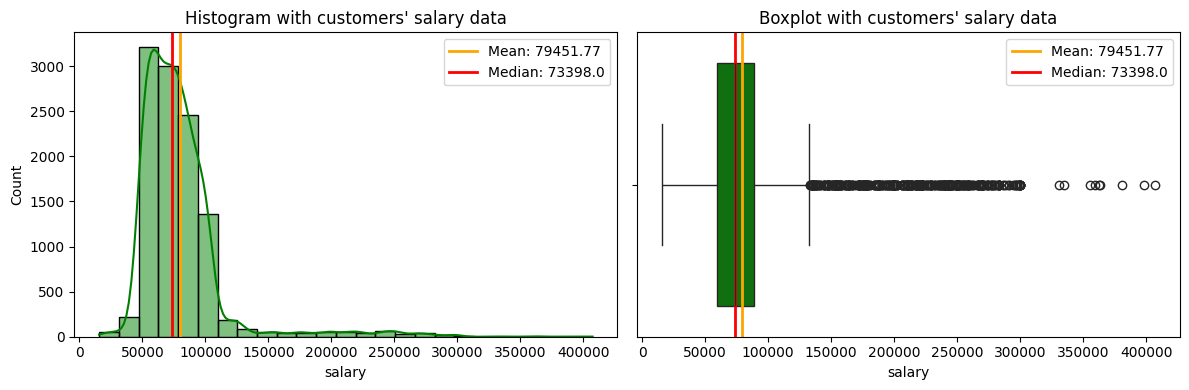

In [57]:
# Let's visualize the salary mean and median with an histogram and a boxplot below:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
# Histogram
sns.histplot(data=df_customers, x= "salary", bins=25, color ="green",ax=axes[0],kde=True)
axes[0].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[0].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[0].legend()
axes[0].set_title("Histogram with customers' salary data")

# Boxplot
sns.boxplot(data=df_customers, x= "salary", color ="green",ax=axes[1])
axes[1].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[1].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].set_title("Boxplot with customers' salary data");
axes[1].legend()

plt.tight_layout()
plt.show();

In [58]:
# As identified when looking at the df.describe():
# With the histogram we can see the distribution of the customers' salaries. Most of the salaries are in the lower range. 
# The distribution is right-skweded (the very few high salaries are extending the tail to the right --> mean higher than the median).
# The boxplot also shows the salary distribution and helps us identify the outliers.
# The "box" (interquartile range) is towards the lower values, meaning that most of the customers have lower salaries.
# There are many outliers on the right side which influence the whole distribution.

In [60]:
# LET'S ANALYSE SOME DISPERSION MEASUREMENTS:
var_salary = round(df_customers["salary"].var(),2)
std_salary = round(df_customers["salary"].std(),2)
print(f"The variance of the salary is: {var_salary}.")
print(f"The standard deviation of the salary is: {std_salary}.")

The variance of the salary is: 1225293391.69.
The standard deviation of the salary is: 35004.19.


In [ ]:
# Both assess the dispersion of the values in comparison with the mean. 
# However, the standard deviation provide us the value in the same unit as the data. 
# To be able to compare different data, it is better to use the coefficient of variation (CV) which is the ration between the standard deviation and the mean.

In [ ]:
# SALARY CV CALCULATION:
cv_salary = round(std_salary / mean_salary * 100,2)
print(f"The coefficient of variance (CV) is {cv_salary}.")
# Values above 30 mean that there is a high dispersion of the data (expected after seeing the histogram and boxplot).

The coefficient of variance (CV) is 44.06.


Let's do the same for the flights dataframe: 

In [68]:
col_numerical_flights

Index(['loyalty_number', 'year', 'flights_booked', 'flights_with_companions',
       'total_flights', 'distance', 'points_accumulated', 'points_redeemed',
       'dollar_cost_points_redeemed'],
      dtype='str')

### 2. Outlier values identification

Customers dataframe:

In [65]:
IQR_salary = df_customers["salary"].quantile(0.75) - df_customers["salary"].quantile(0.25)

salary_inferior_limit = df_customers["salary"].quantile(0.25) - 1.5 * IQR_salary
salary_superior_limit = df_customers["salary"].quantile(0.75) + 1.5 * IQR_salary

superior_mask_salary = df_customers["salary"] > salary_superior_limit
inferior_mask_salary = df_customers["salary"] < salary_inferior_limit

outliers_filter_salary = df_customers[inferior_mask_salary | superior_mask_salary]

outliers_filter_salary["salary"].describe()

count       471.000000
mean     213834.507431
std       49488.443663
min      133080.000000
25%      174791.000000
50%      211255.000000
75%      250152.000000
max      407228.000000
Name: salary, dtype: float64

In [ ]:
# We have 471 outliers where the min value is 133000 and the maximum value is 407228.
# There are not many outliers but they have a strong influence on the salary distribution.

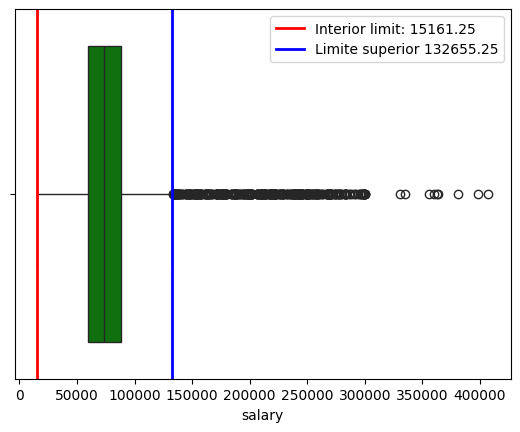

In [67]:
sns.boxplot(data=df_customers, x = "salary", color="green")

plt.axvline(round(salary_inferior_limit,2) , color = "red", linestyle = "-", linewidth = 2, label = f"Interior limit: {round(salary_inferior_limit,2)}")
plt.axvline(round(salary_superior_limit,2), color = "blue", linestyle = "-", linewidth = 2, label = f"Limite superior {round(salary_superior_limit,2)}")

plt.legend();

### 3. Correlation analysis

In [ ]:
# aqui tendremos que usar el merged df

## 2. Categorical variables analysis

### Frequencies distribution